#Avances 2 del proyecto

##Introducción

La deserción estudiantil es una problemática que afecta a muchas instituciones educativas debido a las consecuencias académicas, económicas y sociales que genera tanto para los estudiantes como para las universidades. Detectar de manera temprana a los estudiantes con riesgo de abandono permite implementar estrategias de acompañamiento y apoyo académico con el fin de mejorar la permanencia estudiantil.

En este proyecto se implementaron técnicas de aprendizaje supervisado para predecir el abandono estudiantil utilizando el dataset “Predict Students' Dropout and Academic Success”. El objetivo principal consiste en identificar patrones asociados al rendimiento académico y a la probabilidad de deserción de los estudiantes.

Para el desarrollo del proyecto se utilizaron diferentes modelos de Machine Learning, entre ellos Decision Tree Classifier, Random Forest Classifier, Gaussian Naive Bayes y Support Vector Machine (SVM), evaluando su desempeño mediante métricas de clasificación y validación cruzada.

Uno de los principales retos del proyecto corresponde al desbalance de clases presente en el dataset, debido a que la cantidad de estudiantes que no abandonan es superior respecto a los estudiantes que sí presentan deserción. Este comportamiento puede afectar la capacidad predictiva de los modelos y generar dificultades en la identificación correcta de estudiantes en riesgo.

Por esta razón, se utilizaron métricas como Recall y F1-Score, las cuales permiten evaluar de manera más adecuada el comportamiento de los modelos frente a clases desbalanceadas.

##DESCRIPCIÓN DEL DATASET

El dataset utilizado en este proyecto corresponde al conjunto de datos “Predict Students’ Dropout and Academic Success”, el cual contiene información académica y socioeconómica de estudiantes pertenecientes al Instituto Politécnico de Portalegre (IPP), en Portugal.
El objetivo principal del dataset es permitir la identificación temprana de estudiantes con riesgo de deserción académica mediante técnicas de aprendizaje supervisado.
El conjunto de datos incluye variables relacionadas con:

•	Información demográfica

•	Rendimiento académico

•	Información económica

•	Estado civil

•	Variables institucionales

•	Información de matrícula

Cada registro representa un estudiante y la variable objetivo corresponde al estado académico final del estudiante, permitiendo clasificar si el estudiante presenta riesgo de abandono o permanencia.
Inicialmente se realizó una exploración general del dataset para identificar:
•	cantidad de registros
•	tipos de datos
•	variables categóricas y numéricas
•	presencia de valores nulos
•	distribución de clases
Este análisis exploratorio permite comprender mejor la estructura de los datos y facilita la selección de estrategias adecuadas de preprocesamiento y modelado.


## librerias

In [ ]:

import os
import numpy as np
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

## Montar el drive

In [ ]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Proyecto/Segundo dataset/data.csv';
df = pd.read_csv(path, sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Información básica

In [ ]:
# Mostrar información básica
print("df shape:", df.shape)
df
print("\nPrimeras filas del df:")
display(df.head())


df shape: (4424, 37)

Primeras filas del df:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


##Variable objetivo

"Dropout" Esta variable representa la deserción de los estudiantes en los cursos a partir de dos posible valores 2, 1 y 0  que significan si el estudiante ingreso, aprovo o abandono el curso respectivamente.

In [ ]:
df['Target'] = df['Target'].replace({
    'Graduate': 0,
    'Dropout': 1,
    'Enrolled': 0
})

df['Target'].value_counts()

/tmp/ipykernel_2074/3125378057.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace({


,count
Target,
0,3003
1,1421


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Visualizando las divisiones de StratifiedKFold

Para ver cómo StratifiedKFold divide los datos, podemos iterar a través de los diferentes folds (particiones) y observar la distribución de la variable objetivo (y) tanto en los conjuntos de entrenamiento como en los de prueba para cada división.

Esto ayuda a confirmar que las proporciones de las clases se mantienen de manera equilibrada en todos los folds.

In [ ]:
print("Class distribution in the full dataset:")
display(y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    print(f"\n--- Fold {fold + 1} ---")
    print("Train set class distribution:")
    display(y_train_fold.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

    print("Test set class distribution:")
    display(y_test_fold.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Class distribution in the full dataset:


,proportion
Target,
0,67.88%
1,32.12%



--- Fold 1 ---
Train set class distribution:


,proportion
Target,
0,67.9%
1,32.1%


Test set class distribution:


...

,proportion
Target,
0,67.91%
1,32.09%



--- Fold 5 ---
Train set class distribution:


,proportion
Target,
0,67.88%
1,32.12%


Test set class distribution:


,proportion
Target,
0,67.87%
1,32.13%


#20 variables con más correlación

In [ ]:
#20 variables con más correlación
numeric = df.select_dtypes(include=np.number).columns
cor = df[numeric].corr()
columnas = cor["Target"].sort_values(ascending=False).head(21).index.tolist()

##Eliminamos el tareget

In [ ]:
columnas.remove("Target")

In [ ]:
columnas

['Age at enrollment',
 'Debtor',
 'Gender',
 'Application mode',
 'Marital status',
 'Curricular units 2nd sem (without evaluations)',
 "Mother's qualification",
 'Curricular units 1st sem (without evaluations)',
 'Previous qualification',
 'Inflation rate',
 "Father's qualification",
 'Unemployment rate',
 'Nacionality',
 'Educational special needs',
 'International',
 "Mother's occupation",
 "Father's occupation",
 'Curricular units 1st sem (credited)',
 'Curricular units 2nd sem (credited)',
 'Course']

In [ ]:
columnas_patron=['Course', 'Age at enrollment', "Mother's qualification",
       "Mother's occupation", 'Application mode',
       "Father's qualification", "Father's occupation",
       'Previous qualification', 'Debtor',
       'Curricular units 1st sem (without evaluations)']

###20 primeras columnas(Features)

In [ ]:
X = df[columnas]

In [ ]:
X_patron = df[columnas_patron]

###Variable objetivo

In [ ]:
y = df['Target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#DECISION TREE

Mejores parámetros:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

Mejor F1-SCORE (CV):
0.6647939158255102


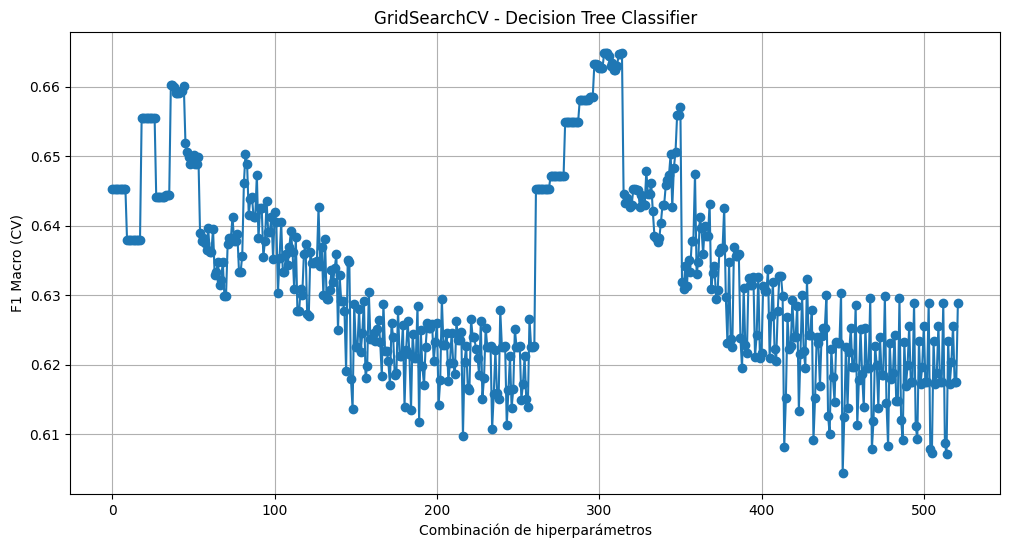


=== CLASSIFICATION REPORT (TEST FINAL) ===
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       601
           1       0.56      0.56      0.56       284

    accuracy                           0.72       885
   macro avg       0.67      0.68      0.67       885
weighted avg       0.72      0.72      0.72       885



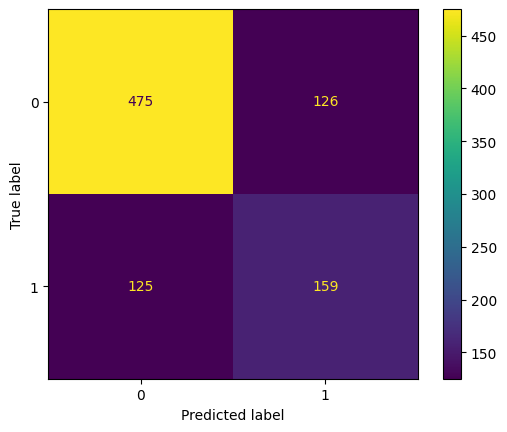

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt



# =========================================================
# 🟡 2. MODELO BASE
# =========================================================
model = DecisionTreeClassifier(random_state=0)

param_grid = {

    'max_depth': range(1, 30),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# =========================================================
# 🟠 3. GRIDSEARCH (SOLO TRAIN)
# =========================================================
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================================
# 🟣 4. MEJOR MODELO
# =========================================================
best_model = grid.best_estimator_

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor F1-SCORE (CV):")
print(grid.best_score_)

# =========================================================
# 🟠 5. GRÁFICA DEL GRIDSEARCH (ANÁLISIS INTERNO)
# =========================================================
results = pd.DataFrame(grid.cv_results_)

scores = results['mean_test_score']
models = range(len(scores))

plt.figure(figsize=(12,6))
plt.plot(models, scores, marker='o')

plt.xlabel("Combinación de hiperparámetros")
plt.ylabel("F1 Macro (CV)")
plt.title("GridSearchCV - Decision Tree Classifier")
plt.grid(True)

plt.show()

# =========================================================
# 🔴 6. EVALUACIÓN FINAL (TEST REAL - SIN LEAKAGE)
# =========================================================
y_pred = best_model.predict(X_test)

print("\n=== CLASSIFICATION REPORT (TEST FINAL) ===")
print(classification_report(y_test, y_pred))

# =========================================================
# ⚫ 7. MATRIZ DE CONFUSIÓN (RECOMENDADO)
# =========================================================
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.show()


##Interpretación de Resultados

Los resultados muestran que el modelo Decision Tree tuvo un rendimiento aceptable para clasificar estudiantes, logrando un accuracy general del 72%.

El modelo identificó mucho mejor a los estudiantes de la clase 0, ya que obtuvo valores de precision y recall cercanos a 0.79. Esto significa que el árbol logró reconocer correctamente gran parte de los estudiantes que no presentaban riesgo de deserción.

Sin embargo, para la clase 1 (Dropout), el desempeño fue más bajo, obteniendo un F1-score de 0.56. Esto indica que el modelo todavía tuvo dificultades para detectar correctamente algunos estudiantes que realmente abandonaron sus estudios.

Esto ocurre principalmente debido al desbalance de clases presente en el dataset, ya que existen más estudiantes de una clase que de la otra. Como consecuencia, el modelo aprende con mayor facilidad la clase mayoritaria y presenta más errores al identificar casos de dropout.

Aun así, limitar la profundidad del árbol ayudó a reducir problemas de overfitting y permitió obtener un modelo más estable y generalizable.

#RANDOM FOREST

Mejores parámetros encontrados:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Mejor F1 SCORE (CV):
0.6871701459117304


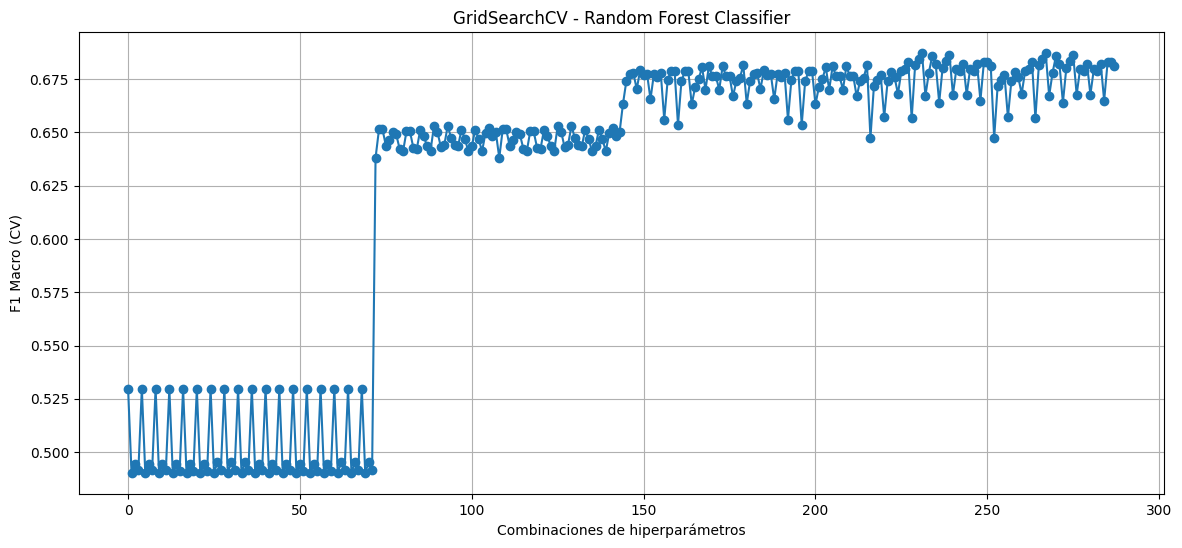


=== CLASSIFICATION REPORT (TEST FINAL) ===
              precision    recall  f1-score   support

           0       0.77      0.89      0.82       601
           1       0.65      0.43      0.52       284

    accuracy                           0.74       885
   macro avg       0.71      0.66      0.67       885
weighted avg       0.73      0.74      0.72       885



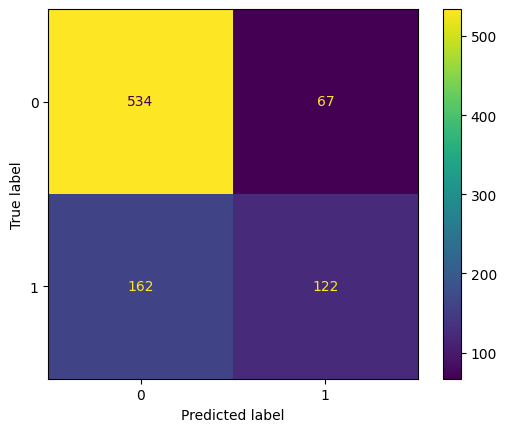

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 🟡 1. MODELO BASE
# =========================================================
model = RandomForestClassifier(random_state=0)

param_grid = {

    'n_estimators': [10, 50, 100, 200],
    'max_depth': [2, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# =========================================================
# 🟠 2. GRIDSEARCH (SOLO TRAIN)
# =========================================================
grid_rf = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',   # ✔ CORREGIDO
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# =========================================================
# 🟣 3. MEJOR MODELO
# =========================================================
best_model_rf = grid_rf.best_estimator_

print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)

print("\nMejor F1 SCORE (CV):")
print(grid_rf.best_score_)

# =========================================================
# 🟠 4. GRÁFICA (ANÁLISIS INTERNO DEL GRIDSEARCH)
# =========================================================
results = pd.DataFrame(grid_rf.cv_results_)

scores = results['mean_test_score']
models = range(len(scores))

plt.figure(figsize=(14,6))
plt.plot(models, scores, marker='o')

plt.xlabel("Combinaciones de hiperparámetros")
plt.ylabel("F1 Macro (CV)")
plt.title("GridSearchCV - Random Forest Classifier")

plt.grid(True)
plt.show()

# =========================================================
# 🔴 5. EVALUACIÓN FINAL (TEST REAL - SIN LEAKAGE)
# =========================================================
y_pred = best_model_rf.predict(X_test)

print("\n=== CLASSIFICATION REPORT (TEST FINAL) ===")
print(classification_report(y_test, y_pred))

# =========================================================
# ⚫ 6. MATRIZ DE CONFUSIÓN
# =========================================================
ConfusionMatrixDisplay.from_estimator(
    best_model_rf,
    X_test,
    y_test
)
plt.show()

In [ ]:
best_model_rf = grid_rf.best_estimator_

##Interpretación de Resultados

Los resultados muestran que Random Forest fue uno de los modelos con mejor rendimiento general dentro del proyecto, alcanzando un accuracy del 74%.

El modelo logró clasificar muy bien la clase 0, obteniendo un recall de 0.89 y un F1-score de 0.82, lo que indica que pudo reconocer correctamente la mayoría de estudiantes que no presentaban riesgo de deserción.

Para la clase 1 (Dropout), el modelo obtuvo un F1-score de 0.52 y un recall de 0.43. Aunque todavía existen dificultades para detectar algunos estudiantes dropout, el modelo presentó un comportamiento más estable y generalizable en comparación con Decision Tree.

Esto se debe a que Random Forest combina múltiples árboles de decisión, reduciendo problemas de overfitting y mejorando la capacidad de aprendizaje sobre diferentes patrones del dataset.

Además, el modelo obtuvo el mejor F1-score promedio durante la validación cruzada, lo que indica un mejor equilibrio entre precisión y capacidad de generalización.

#GAUSSIAN NAIVE BAYES

Mejores parámetros encontrados:
{'var_smoothing': np.float64(8.858667904100832e-09)}

Mejor F1 SCORE (CV):
0.6318286220372815


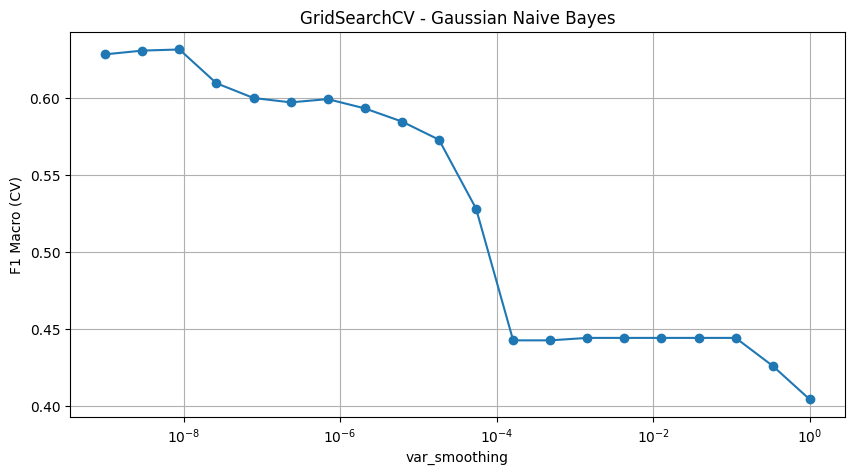


=== CLASSIFICATION REPORT (TEST FINAL) ===
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       601
           1       0.55      0.40      0.46       284

    accuracy                           0.70       885
   macro avg       0.65      0.62      0.63       885
weighted avg       0.69      0.70      0.69       885



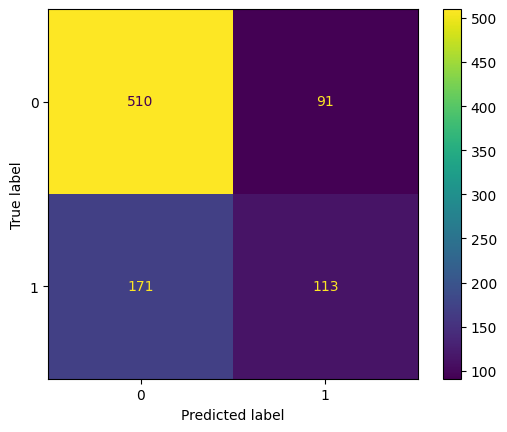

In [ ]:

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 🟡 1. MODELO BASE
# =========================================================
model = GaussianNB()

param_grid = {

    'var_smoothing': np.logspace(0, -9, 20)
}

# =========================================================
# 🟠 2. GRIDSEARCH (SOLO TRAIN)
# =========================================================
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',   # ✔ CORREGIDO
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================================
# 🟣 3. MEJOR MODELO
# =========================================================
best_model = grid.best_estimator_

print("Mejores parámetros encontrados:")
print(grid.best_params_)

print("\nMejor F1 SCORE (CV):")
print(grid.best_score_)

# =========================================================
# 🟠 4. GRÁFICA DEL GRIDSEARCH
# =========================================================
results = pd.DataFrame(grid.cv_results_)

scores = results['mean_test_score']
values = results['param_var_smoothing']

plt.figure(figsize=(10,5))
plt.plot(values, scores, marker='o')
plt.xscale('log')

plt.xlabel("var_smoothing")
plt.ylabel("F1 Macro (CV)")
plt.title("GridSearchCV - Gaussian Naive Bayes")

plt.grid(True)
plt.show()

# =========================================================
# 🔴 5. EVALUACIÓN FINAL (TEST REAL)
# =========================================================
y_pred = best_model.predict(X_test)

print("\n=== CLASSIFICATION REPORT (TEST FINAL) ===")
print(classification_report(y_test, y_pred))

# =========================================================
# ⚫ 6. MATRIZ DE CONFUSIÓN
# =========================================================
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.show()

##Interpretación de Resultados

Los resultados obtenidos muestran que Gaussian Naive Bayes tuvo un desempeño moderado en la clasificación de estudiantes.

El modelo alcanzó un accuracy del 70%, logrando mejores resultados sobre la clase 0, donde obtuvo un F1-score de 0.80. Esto significa que pudo clasificar correctamente gran parte de estudiantes que permanecen en el sistema educativo.

Sin embargo, para la clase 1 (Dropout), el desempeño fue menor, alcanzando un F1-score de 0.46 y un recall de 0.40. Esto indica que el modelo presentó dificultades para identificar correctamente algunos estudiantes con riesgo de abandono.

Una posible razón es que Gaussian Naive Bayes asume independencia entre variables, mientras que en este dataset muchas características académicas y socioeconómicas pueden estar relacionadas entre sí.

A pesar de sus limitaciones, el modelo destacó por su rapidez de entrenamiento y simplicidad computacional, siendo una alternativa eficiente para realizar clasificaciones básicas.

#Support Vector Machine (SVM)

Mejores parámetros encontrados:
{'svc__C': 10, 'svc__degree': 2, 'svc__gamma': 'auto', 'svc__kernel': 'poly'}

Mejor F1 SCORE (CV):
0.6174748080618482


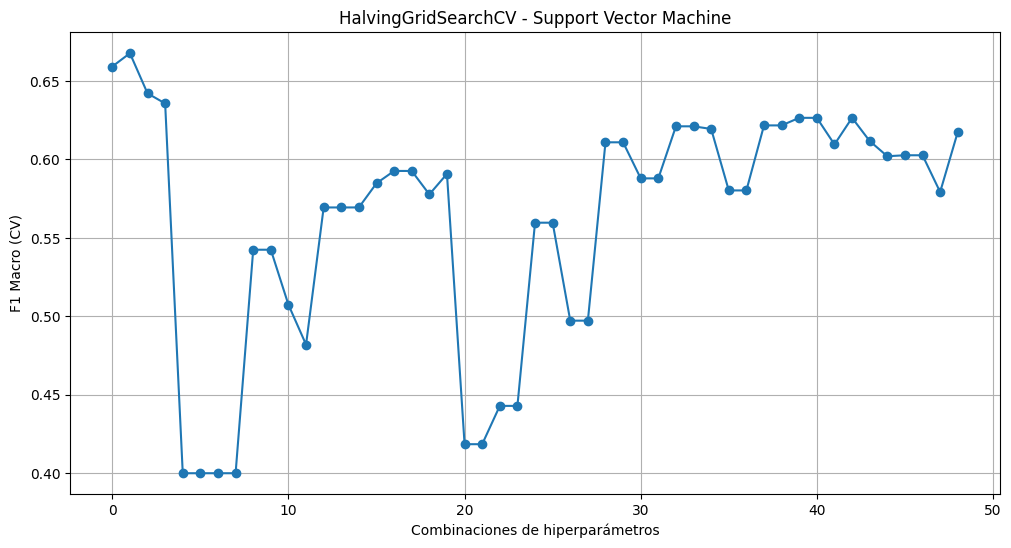


=== CLASSIFICATION REPORT (TEST FINAL) ===
              precision    recall  f1-score   support

           0       0.73      0.92      0.82       601
           1       0.63      0.29      0.40       284

    accuracy                           0.72       885
   macro avg       0.68      0.61      0.61       885
weighted avg       0.70      0.72      0.68       885



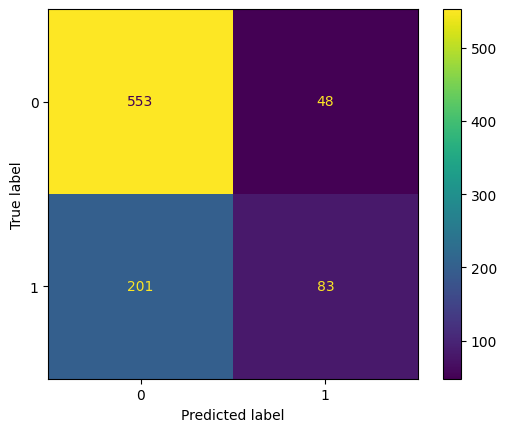

In [ ]:

from sklearn.experimental import enable_halving_search_cv
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 🟡 1. PIPELINE (ESCALADO + MODELO)
# =========================================================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# =========================================================
# 🟠 2. GRID DE HIPERPARÁMETROS
# =========================================================
param_grid = [

    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100]
    },

    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.1, 0.01]
    },

    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto'],
        'svc__degree': [2, 3]
    }
]

# =========================================================
# 🟣 3. HALVING GRID SEARCH (SOLO TRAIN)
# =========================================================
grid = HalvingGridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',   # ✔ CORREGIDO
    n_jobs=-1,
    random_state=42
)

grid.fit(X_train, y_train)

# =========================================================
# 🟢 4. MEJOR MODELO
# =========================================================
best_model = grid.best_estimator_

print("Mejores parámetros encontrados:")
print(grid.best_params_)

print("\nMejor F1 SCORE (CV):")
print(grid.best_score_)

# =========================================================
# 🟠 5. GRÁFICA (ANÁLISIS INTERNO)
# =========================================================
results = pd.DataFrame(grid.cv_results_)

scores = results['mean_test_score']
models = range(len(scores))

plt.figure(figsize=(12,6))
plt.plot(models, scores, marker='o')

plt.xlabel("Combinaciones de hiperparámetros")
plt.ylabel("F1 Macro (CV)")
plt.title("HalvingGridSearchCV - Support Vector Machine")

plt.grid(True)
plt.show()

# =========================================================
# 🔴 6. EVALUACIÓN FINAL (TEST REAL)
# =========================================================
y_pred = best_model.predict(X_test)

print("\n=== CLASSIFICATION REPORT (TEST FINAL) ===")
print(classification_report(y_test, y_pred))

# =========================================================
# ⚫ 7. MATRIZ DE CONFUSIÓN
# =========================================================
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.show()

##Interpretación de Resultados

Los resultados muestran que SVM logró un accuracy general del 72%, presentando un muy buen desempeño en la clasificación de la clase 0.

El modelo obtuvo un recall de 0.92 para la clase 0, indicando que pudo identificar correctamente la mayoría de estudiantes sin riesgo de deserción.

Sin embargo, para la clase 1 (Dropout), el recall fue de 0.29 y el F1-score de 0.40, evidenciando dificultades importantes para detectar estudiantes que realmente abandonaron sus estudios.

Esto puede deberse al desbalance de clases presente en el dataset, ya que SVM tiende a favorecer la clase mayoritaria cuando existen diferencias significativas en la cantidad de muestras.

Aun así, el modelo mostró una buena capacidad para construir fronteras de decisión complejas gracias al uso del kernel polinomial, permitiendo separar parcialmente patrones no lineales dentro de los datos.

#Construcción del Error DataFrame

En esta sección se construye un DataFrame auxiliar que permite identificar los errores cometidos por el modelo, así como analizar la confianza de las predicciones y detectar patrones asociados a clasificaciones incorrectas

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Compatible con SVC, RandomForest, Pipeline, cualquier estimador
if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(X_test)
    proba_max = proba.max(axis=1)
else:
    scores = best_model.decision_function(X_test)
    if scores.ndim == 1:
        proba_max = np.abs(scores)
    else:
        proba_max = scores.max(axis=1)
    proba_max = (proba_max - proba_max.min()) / (np.ptp(proba_max) + 1e-9)

error_df = X_test.copy().reset_index(drop=True)
error_df['y_true']    = np.array(y_test).flatten()
error_df['y_pred']    = y_pred
error_df['proba_max'] = proba_max
error_df['is_error']  = (error_df['y_true'] != error_df['y_pred']).astype(int)

print(f"Total errores: {error_df['is_error'].sum()} / {len(error_df)}")
print(f"Tasa de error global: {error_df['is_error'].mean():.2%}")


Total errores: 249 / 885
Tasa de error global: 28.14%


#Tasa de Error por Subgrupos

El objetivo de esta sección consiste en identificar si existen grupos específicos de estudiantes donde el modelo presenta mayores dificultades de clasificación.

El análisis se realiza considerando variables como:

estado civil

condición económica

internacionalización

programa académico


=== TASA DE ERROR POR DEBTOR ===
        tasa_error  n_errores  n_total
Debtor                                
1         0.333333         30       90
0         0.275472        219      795


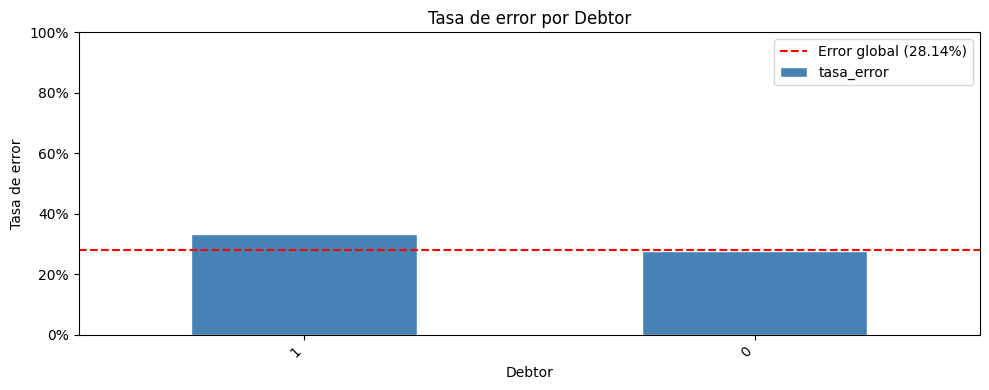


=== TASA DE ERROR POR INTERNATIONAL ===
               tasa_error  n_errores  n_total
International                                
1                0.346154          9       26
0                0.279395        240      859


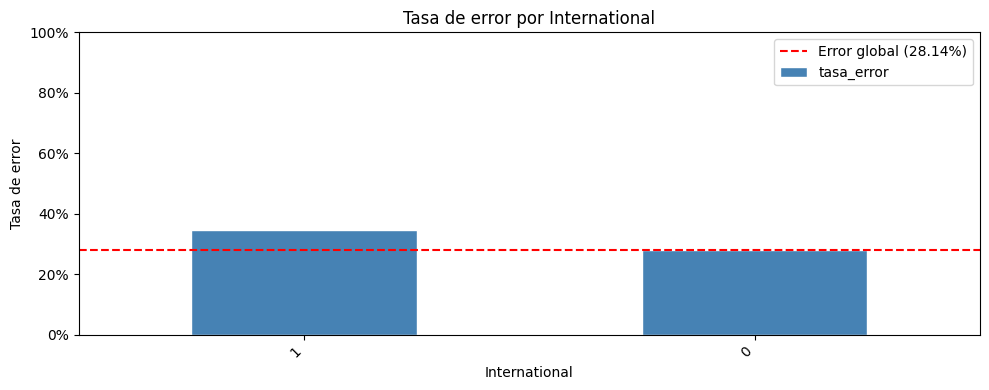


=== TASA DE ERROR POR MARITAL STATUS ===
                tasa_error  n_errores  n_total
Marital status                                
6                 0.500000          1        2
2                 0.433735         36       83
4                 0.409091          9       22
5                 0.333333          1        3
1                 0.260645        202      775


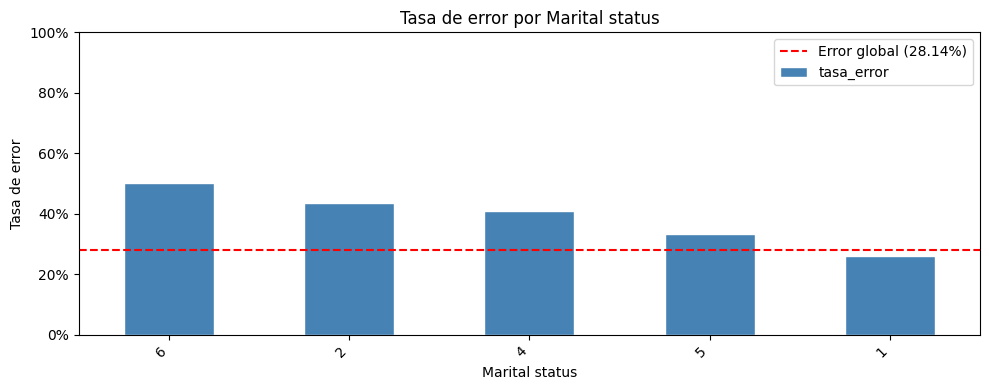


=== TASA DE ERROR POR COURSE ===
        tasa_error  n_errores  n_total
Course                                
33        0.666667          4        6
9853      0.540541         20       37
9119      0.454545         15       33
171       0.446809         21       47
9130      0.407407         11       27
9991      0.372549         19       51
9147      0.320513         25       78
9773      0.318841         22       69
8014      0.304348         14       46
9003      0.285714         12       42
9670      0.285714         18       63
9556      0.277778          5       18
9254      0.240741         13       54
9085      0.203704         11       54
9070      0.176471          6       34
9500      0.152866         24      157
9238      0.130435          9       69


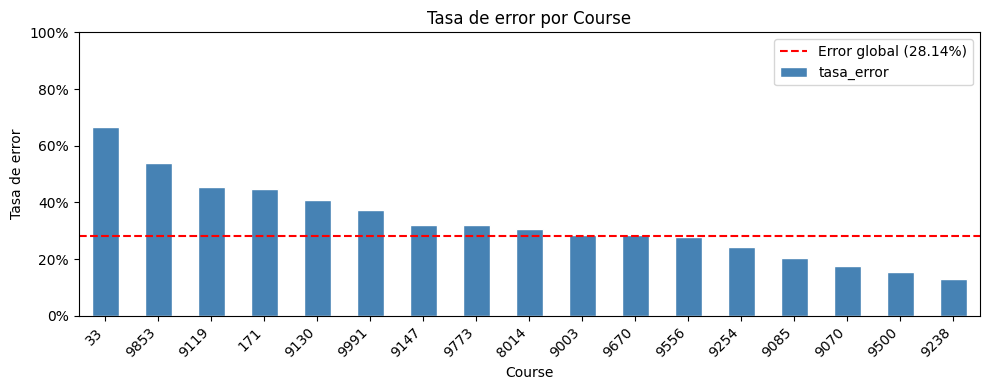

In [ ]:
subgrupos = [ 'Debtor', 'International', 'Marital status', 'Course']

for subgrupo in subgrupos:
    error_rate_by_group = (
        error_df.groupby(subgrupo)['is_error']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'tasa_error', 'sum': 'n_errores', 'count': 'n_total'})
        .sort_values('tasa_error', ascending=False)
    )
    print(f"\n=== TASA DE ERROR POR {subgrupo.upper()} ===")
    print(error_rate_by_group)

    fig, ax = plt.subplots(figsize=(10, 4))
    error_rate_by_group['tasa_error'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.axhline(error_df['is_error'].mean(), color='red', linestyle='--', label=f'Error global ({error_df["is_error"].mean():.2%})')
    ax.set_title(f"Tasa de error por {subgrupo}")
    ax.set_ylabel("Tasa de error")
    ax.set_xlabel(subgrupo)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


#Errores de Alta Confianza

Esta sección analiza aquellas predicciones incorrectas donde el modelo presentó una alta confianza en su decisión.

Este tipo de errores resulta especialmente importante debido a que indica posibles zonas de superposición entre clases o limitaciones en las variables utilizadas.


=== TOP 20 ERRORES MÁS CONFIADOS ===
     y_true  y_pred  proba_max
346       1       0   0.637021
149       1       0   0.573769
848       1       0   0.524540
188       1       0   0.488979
796       0       1   0.484252
567       0       1   0.417357
702       1       0   0.399423
86        1       0   0.328822
735       0       1   0.295630
100       0       1   0.224032
145       1       0   0.223843
33        1       0   0.200199
396       1       0   0.195671
443       1       0   0.181803
446       1       0   0.180793
654       1       0   0.166044
74        1       0   0.135053
589       1       0   0.132955
597       0       1   0.115053
658       0       1   0.111452


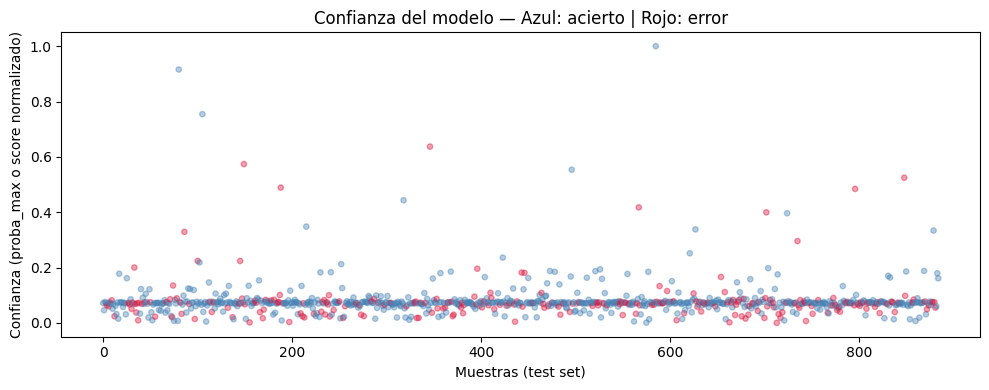

In [ ]:
high_conf_errors = (
    error_df[error_df['is_error'] == 1]
    .sort_values('proba_max', ascending=False)
    .head(20)
)

print("\n=== TOP 20 ERRORES MÁS CONFIADOS ===")
print(high_conf_errors[['y_true', 'y_pred', 'proba_max']].to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colores = error_df['is_error'].map({0: 'steelblue', 1: 'crimson'})
ax.scatter(range(len(error_df)), error_df['proba_max'],
           c=colores, alpha=0.4, s=15)
ax.set_title("Confianza del modelo — Azul: acierto | Rojo: error")
ax.set_ylabel("Confianza (proba_max o score normalizado)")
ax.set_xlabel("Muestras (test set)")
plt.tight_layout()
plt.show()


#Distribución de Variables en Errores y Aciertos

En esta sección se comparan las distribuciones de las variables más importantes entre predicciones correctas e incorrectas.

El objetivo consiste en identificar patrones que expliquen las dificultades del modelo al clasificar determinados perfiles estudiantiles.

⚠️  Sin feature_importances_: usando las primeras 4 features.


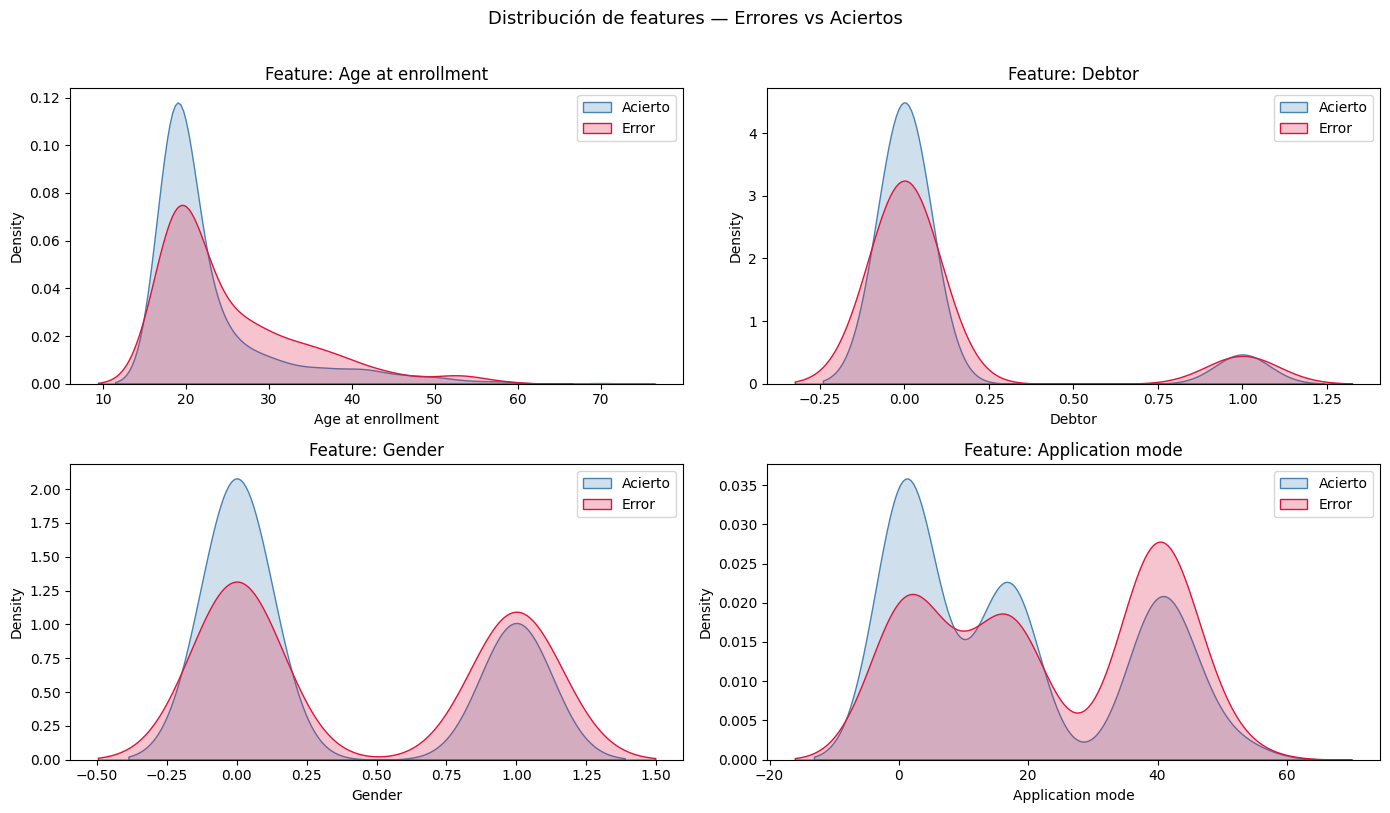

In [ ]:
feature_names = X_test.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_features = [feature_names[i] for i in np.argsort(importances)[::-1][:4]]
elif hasattr(best_model, 'named_steps'):
    last_step = list(best_model.named_steps.values())[-1]
    if hasattr(last_step, 'feature_importances_'):
        importances = last_step.feature_importances_
        top_features = [feature_names[i] for i in np.argsort(importances)[::-1][:4]]
    else:
        top_features = feature_names[:4]
        print("⚠️  Sin feature_importances_: usando las primeras 4 features.")
else:
    top_features = feature_names[:4]
    print("⚠️  Sin feature_importances_: usando las primeras 4 features.")

top_features = [f for f in top_features if pd.api.types.is_numeric_dtype(error_df[f])][:4]

if top_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        ax = axes[i]
        for label, grp in error_df.groupby('is_error'):
            color = 'crimson' if label == 1 else 'steelblue'
            name  = 'Error' if label == 1 else 'Acierto'
            sns.kdeplot(grp[feat], ax=ax, label=name, color=color, fill=True, alpha=0.25)
        ax.set_title(f"Feature: {feat}")
        ax.set_xlabel(feat)
        ax.legend()

    for j in range(len(top_features), 4):
        axes[j].set_visible(False)

    plt.suptitle("Distribución de features — Errores vs Aciertos", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No se encontraron features numéricas para graficar.")


#Diagnóstico Técnico por Clase

Esta sección evalúa el comportamiento del modelo para cada clase utilizando métricas como Precision, Recall y F1-score.

Además, se analiza la confianza promedio de las predicciones para identificar posibles problemas de desbalance, overlap o debilidad en las variables predictoras.


=== DIAGNÓSTICO POR CLASE ===
Clase  F1-score  Precision  Recall  Soporte  Confianza_prom
    1     0.400      0.634   0.292    284.0           0.079
    0     0.816      0.733   0.920    601.0           0.082


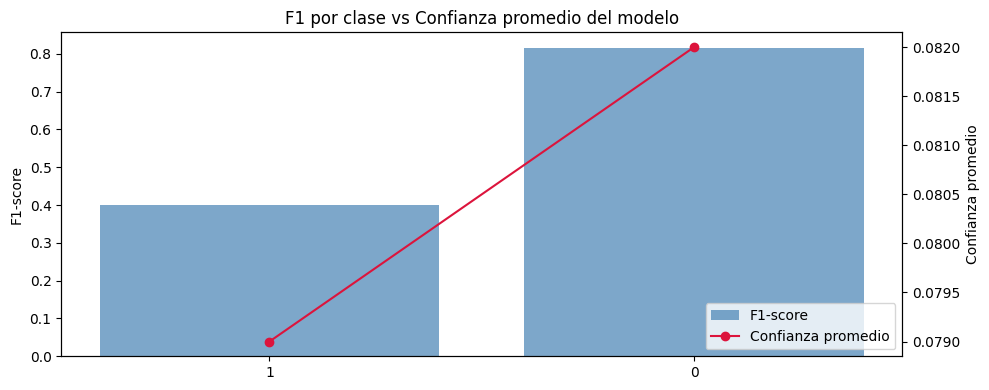

In [ ]:
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, output_dict=True)
clases = [k for k in report_dict if k not in ('accuracy', 'macro avg', 'weighted avg')]

resumen_clase = []
for clase in clases:
    mask_true = error_df['y_true'].astype(str) == str(clase)
    avg_proba  = error_df.loc[mask_true, 'proba_max'].mean()
    resumen_clase.append({
        'Clase':          clase,
        'F1-score':       round(report_dict[clase]['f1-score'], 3),
        'Precision':      round(report_dict[clase]['precision'], 3),
        'Recall':         round(report_dict[clase]['recall'], 3),
        'Soporte':        report_dict[clase]['support'],
        'Confianza_prom': round(avg_proba, 3),
    })

df_clases = pd.DataFrame(resumen_clase).sort_values('F1-score')
print("\n=== DIAGNÓSTICO POR CLASE ===")
print(df_clases.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4))
x  = range(len(df_clases))
ax2 = ax1.twinx()

ax1.bar(x, df_clases['F1-score'], color='steelblue', alpha=0.7, label='F1-score')
ax2.plot(x, df_clases['Confianza_prom'], color='crimson', marker='o', label='Confianza promedio')

ax1.set_xticks(x)
ax1.set_xticklabels(df_clases['Clase'])
ax1.set_ylabel("F1-score")
ax2.set_ylabel("Confianza promedio")
ax1.set_title("F1 por clase vs Confianza promedio del modelo")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

#Diagnóstico Automático del Modelo

Finalmente, se genera un diagnóstico automático que resume los principales problemas detectados durante el análisis de errores.

In [ ]:
clase_peor = df_clases.iloc[0]
print(f"""
╔══════════════════════════════════════════════════════════════╗
║            DIAGNÓSTICO AUTOMÁTICO                           ║
╠══════════════════════════════════════════════════════════════╣

  Clase con peor desempeño: {clase_peor['Clase']}
  F1-score:        {clase_peor['F1-score']}
  Recall:          {clase_peor['Recall']}
  Confianza prom:  {clase_peor['Confianza_prom']}
  Soporte:         {clase_peor['Soporte']}

  Diagnóstico probable:
  {'→ DESBALANCE: soporte bajo + recall bajo' if clase_peor['Soporte'] < 50 else ''}
  {'→ OVERLAP: confianza alta + F1 bajo (el modelo está seguro pero se equivoca)' if clase_peor['Confianza_prom'] > 0.7 and clase_peor['F1-score'] < 0.6 else ''}
  {'→ FEATURES DÉBILES: confianza baja + F1 bajo' if clase_peor['Confianza_prom'] < 0.5 else ''}

╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║            DIAGNÓSTICO AUTOMÁTICO                           ║
╠══════════════════════════════════════════════════════════════╣

  Clase con peor desempeño: 1
  F1-score:        0.4
  Recall:          0.292
  Confianza prom:  0.079
  Soporte:         284.0

  Diagnóstico probable:
  
  
  → FEATURES DÉBILES: confianza baja + F1 bajo

╚══════════════════════════════════════════════════════════════╝



#Análisis de Capacidad Discriminativa de Features
Con el objetivo de comprender qué variables contribuyen de manera más significativa a la correcta identificación de estudiantes con riesgo de deserción, se realizó un análisis de capacidad discriminativa de features.

El procedimiento consistió en comparar las diferencias de medias entre predicciones correctas e incorrectas para la clase Dropout. De esta manera, fue posible identificar cuáles variables permiten separar con mayor claridad a los estudiantes que abandonan sus estudios y cuáles presentan una baja capacidad discriminativa.

Este análisis aporta interpretabilidad al modelo y facilita la comprensión de los factores que influyen en la clasificación realizada por los algoritmos de Machine Learning.


=== FEATURES ORDENADAS DE MEJOR A PEOR PARA CLASIFICAR DROPOUT ===
                                       feature  diferencia  media_acierto  media_error
                                        Course  269.328838    8637.831325  8368.502488
                             Age at enrollment    8.747108      33.204819    24.457711
                        Mother's qualification    6.265240      26.951807    20.686567
                           Mother's occupation    6.254930      15.578313     9.323383
                              Application mode    5.553318      28.120482    22.567164
                        Father's qualification    4.161961      26.530120    22.368159
                           Father's occupation    3.167356      13.132530     9.965174
                        Previous qualification    2.583768       7.409639     4.825871
                                        Debtor    0.575436       0.590361     0.014925
Curricular units 1st sem (without evaluations)    0.380327     

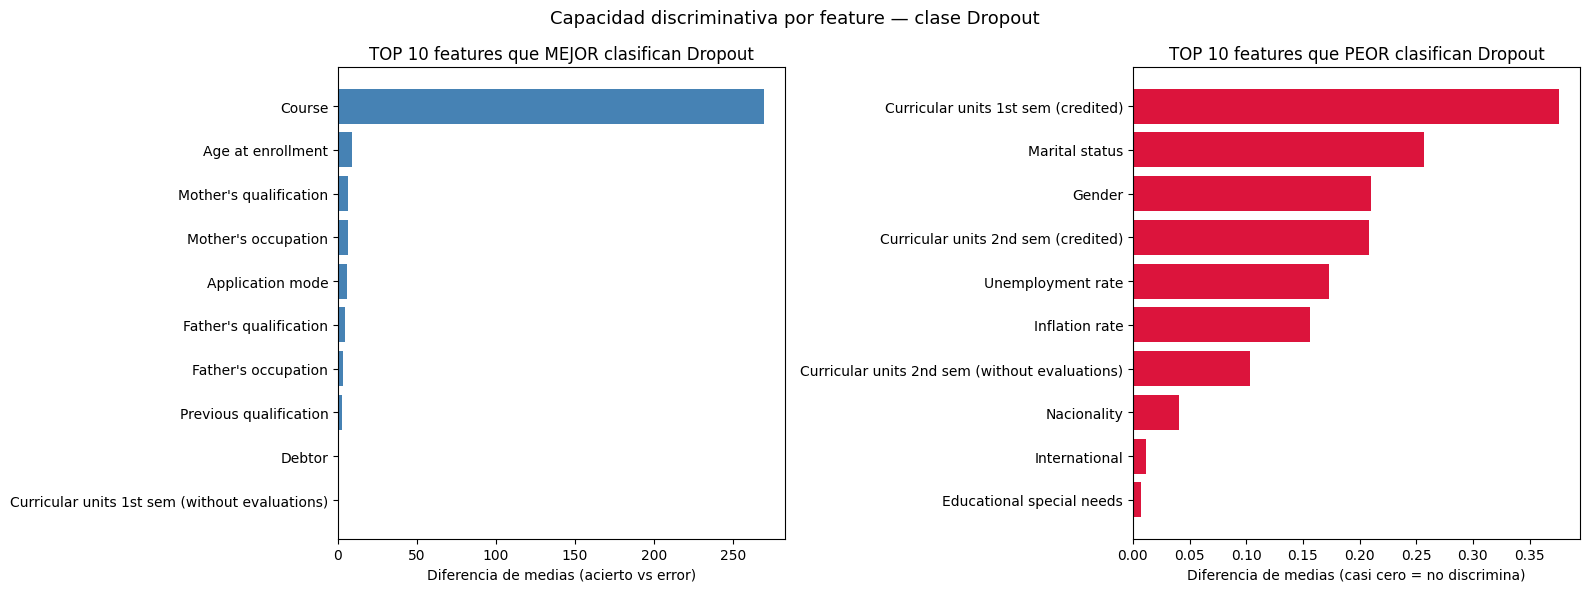


✅ MEJORES features para Dropout:
               feature  diferencia
                Course  269.328838
     Age at enrollment    8.747108
Mother's qualification    6.265240
   Mother's occupation    6.254930
      Application mode    5.553318

❌ PEORES features para Dropout:
                                       feature  diferencia
                                Inflation rate    0.156692
Curricular units 2nd sem (without evaluations)    0.102979
                                   Nacionality    0.040340
                                 International    0.011269
                     Educational special needs    0.007073


In [ ]:
# =========================================================
# FEATURES QUE MEJOR Y PEOR CLASIFICAN DROPOUT
# =========================================================

feature_names = X_test.columns.tolist()

# Separar errores y aciertos SOLO de la clase Dropout (y_true == 1)
dropout_ok   = error_df[(error_df['y_true'] == 1) & (error_df['is_error'] == 0)]
dropout_fail = error_df[(error_df['y_true'] == 1) & (error_df['is_error'] == 1)]

# Diferencia de medias entre aciertos y errores en Dropout
medias_ok   = dropout_ok[feature_names].mean()
medias_fail = dropout_fail[feature_names].mean()

diff = (medias_ok - medias_fail).abs().sort_values(ascending=False)

df_diff = pd.DataFrame({
    'feature':       diff.index,
    'diferencia':    diff.values,
    'media_acierto': medias_ok[diff.index].values,
    'media_error':   medias_fail[diff.index].values,
})

print("=== FEATURES ORDENADAS DE MEJOR A PEOR PARA CLASIFICAR DROPOUT ===")
print(df_diff.to_string(index=False))

# ── Gráfica: TOP 10 MEJORES ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_mejor = df_diff.head(10)
axes[0].barh(top10_mejor['feature'][::-1], top10_mejor['diferencia'][::-1], color='steelblue')
axes[0].set_title("TOP 10 features que MEJOR clasifican Dropout")
axes[0].set_xlabel("Diferencia de medias (acierto vs error)")

# ── Gráfica: TOP 10 PEORES ─────────────────────────────────
top10_peor = df_diff.tail(10)
axes[1].barh(top10_peor['feature'][::-1], top10_peor['diferencia'][::-1], color='crimson')
axes[1].set_title("TOP 10 features que PEOR clasifican Dropout")
axes[1].set_xlabel("Diferencia de medias (casi cero = no discrimina)")

plt.suptitle("Capacidad discriminativa por feature — clase Dropout", fontsize=13)
plt.tight_layout()
plt.show()

# ── Resumen final ──────────────────────────────────────────
print("\n✅ MEJORES features para Dropout:")
print(df_diff.head(5)[['feature', 'diferencia']].to_string(index=False))

print("\n❌ PEORES features para Dropout:")
print(df_diff.tail(5)[['feature', 'diferencia']].to_string(index=False))


##Interpretación de Resultados

Los resultados obtenidos muestran que la variable Course presenta la mayor capacidad discriminativa para la clasificación de estudiantes dropout, evidenciando que el programa académico influye significativamente en el comportamiento de abandono estudiantil.

Asimismo, variables como Age at enrollment, Mother's qualification, Mother's occupation y Application mode también mostraron diferencias importantes entre aciertos y errores, indicando que factores demográficos y socioeconómicos tienen una relación relevante con la permanencia estudiantil.

Por otro lado, variables como International, Educational special needs y Nacionality presentaron diferencias cercanas a cero, lo que sugiere una baja capacidad para distinguir correctamente estudiantes en riesgo de deserción.

Estos resultados evidencian que algunas variables contienen patrones más útiles para el modelo, mientras que otras aportan poca información discriminativa debido a la superposición parcial entre clases.

In [ ]:
top10_mejor = df_diff.head(10)
top10_mejor['feature'].values

array(['Course', 'Age at enrollment', "Mother's qualification",
       "Mother's occupation", 'Application mode',
       "Father's qualification", "Father's occupation",
       'Previous qualification', 'Debtor',
       'Curricular units 1st sem (without evaluations)'], dtype=object)

#VALORES EXACTOS DE CADA SUBGRUPO CON SU TASA DE ERROR

In [ ]:
# =========================================================
# VER VALORES EXACTOS DE CADA SUBGRUPO CON SU TASA DE ERROR
# =========================================================

subgrupos = ['Gender', 'Debtor', 'International', 'Marital status', 'Course']

for subgrupo in subgrupos:
    tabla = (
        error_df.groupby(subgrupo)['is_error']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'tasa_error', 'sum': 'n_errores', 'count': 'n_total'})
        .sort_values('tasa_error', ascending=False)
    )
    print(f"\n=== {subgrupo.upper()} ===")
    print(tabla.to_string())


=== GENDER ===
        tasa_error  n_errores  n_total
Gender                                
1         0.352025        113      321
0         0.241135        136      564

=== DEBTOR ===
        tasa_error  n_errores  n_total
Debtor                                
1         0.333333         30       90
0         0.275472        219      795

=== INTERNATIONAL ===
               tasa_error  n_errores  n_total
International                                
1                0.346154          9       26
0                0.279395        240      859

=== MARITAL STATUS ===
                tasa_error  n_errores  n_total
Marital status                                
6                 0.500000          1        2
2                 0.433735         36       83
4                 0.409091          9       22
5                 0.333333          1        3
1                 0.260645        202      775

=== COURSE ===
        tasa_error  n_errores  n_total
Course                                
33

In [ ]:
# Filtrar solo ese subgrupo problemático
subgrupo_filtrado = error_df[error_df['Marital status'] == 6]

print(f"Tasa de error: {subgrupo_filtrado['is_error'].mean():.2%}")
print(f"Total muestras: {len(subgrupo_filtrado)}")
print(f"Errores: {subgrupo_filtrado['is_error'].sum()}")

Tasa de error: 50.00%
Total muestras: 2
Errores: 1


In [ ]:
subgrupos = ['Gender', 'Debtor', 'International', 'Marital status', 'Course']

for subgrupo in subgrupos:
    tabla = (
        error_df.groupby(subgrupo)['is_error']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'tasa_error', 'sum': 'n_errores', 'count': 'n_total'})
        .sort_values('tasa_error', ascending=False)
    )
    print(f"\n=== {subgrupo.upper()} ===")
    print(tabla.to_string())



=== GENDER ===
        tasa_error  n_errores  n_total
Gender                                
1         0.352025        113      321
0         0.241135        136      564

=== DEBTOR ===
        tasa_error  n_errores  n_total
Debtor                                
1         0.333333         30       90
0         0.275472        219      795

=== INTERNATIONAL ===
               tasa_error  n_errores  n_total
International                                
1                0.346154          9       26
0                0.279395        240      859

=== MARITAL STATUS ===
                tasa_error  n_errores  n_total
Marital status                                
6                 0.500000          1        2
2                 0.433735         36       83
4                 0.409091          9       22
5                 0.333333          1        3
1                 0.260645        202      775

=== COURSE ===
        tasa_error  n_errores  n_total
Course                                
33

In [ ]:
# ── Paso 1: filtrar train ──────────────────────────────────
mask_train_limpio = (
    (X_train['Gender'] != 1) &
    (~X_train['Marital status'].isin([2, 4, 6])) &
    (~X_train['Course'].isin([33, 9853, 9119, 171]))
)
X_train_limpio = X_train[mask_train_limpio]
y_train_limpio = y_train[mask_train_limpio]

print(f"Train original: {len(X_train)} muestras")
print(f"Train limpio:   {len(X_train_limpio)} muestras")


Train original: 3539 muestras
Train limpio:   1847 muestras


In [ ]:
# ── Paso 1: filtrar TRAIN ──────────────────────────────────
mask_train_limpio = (
    (X_train['Gender'] != 1) &
    (~X_train['Marital status'].isin([2, 4, 6])) &
    (~X_train['Course'].isin([33, 9853, 9119, 171]))
)
X_train_limpio = X_train[mask_train_limpio]
y_train_limpio = y_train[mask_train_limpio]

# ── Paso 2: filtrar TEST ───────────────────────────────────
mask_test_limpio = (
    (X_test['Gender'] != 1) &
    (~X_test['Marital status'].isin([2, 4, 6])) &
    (~X_test['Course'].isin([33, 9853, 9119, 171]))
)
X_test_limpio = X_test[mask_test_limpio]
y_test_limpio = y_test[mask_test_limpio]

print(f"Train original: {len(X_train)} | Train limpio: {len(X_train_limpio)}")
print(f"Test original:  {len(X_test)}  | Test limpio:  {len(X_test_limpio)}")

# ── Paso 3: reentrenar ─────────────────────────────────────
model_limpio = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0
)
model_limpio.fit(X_train_limpio, y_train_limpio)
print("✅ Modelo reentrenado")

# ── Paso 4: comparar ───────────────────────────────────────
y_pred_original_en_limpio = best_model.predict(X_test_limpio)

print("\n=== MODELO ORIGINAL (en subset limpio) ===")
print(classification_report(y_test_limpio, y_pred_original_en_limpio))

#print("\n=== MODELO REENTRENADO SIN SUBGRUPOS PROBLEMÁTICOS ===")
##print(classification_report(y_test_limpio, y_pred_limpio))

Train original: 3539 | Train limpio: 1847
Test original:  885  | Test limpio:  451
✅ Modelo reentrenado

=== MODELO ORIGINAL (en subset limpio) ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       364
           1       0.53      0.23      0.32        87

    accuracy                           0.81       451
   macro avg       0.68      0.59      0.61       451
weighted avg       0.78      0.81      0.78       451



In [ ]:
best_model_rf.feature_importances_

array([0.1611972 , 0.06918054, 0.04463253, 0.07001459, 0.01334513,
       0.01374674, 0.06015799, 0.01156192, 0.02459167, 0.05876834,
       0.05829924, 0.0677999 , 0.00376529, 0.00154055, 0.00191713,
       0.08856781, 0.09342304, 0.02537652, 0.02280024, 0.10931362])

In [ ]:
from sklearn.model_selection import train_test_split

X_train_patron, X_test_patron, y_train_patron, y_test_patron = train_test_split(

    X_patron,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# ── Paso 3: reentrenar ─────────────────────────────────────
model_limpio = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0
)
model_limpio.fit(X_train_patron, y_train_patron)
print("✅ Modelo reentrenado")

# ── Paso 4: comparar ───────────────────────────────────────
##y_pred_original_en_limpio = best_model_rf.predict(X_test_limpio)
y_pred_original_en_limpio = model_limpio.predict(X_test_patron)

print("\n=== MODELO ORIGINAL (en subset limpio) ===")
print(classification_report(y_test_patron, y_pred_original_en_limpio))

#print("\n=== MODELO REENTRENADO SIN SUBGRUPOS PROBLEMÁTICOS ===")
##print(classification_report(y_test_limpio, y_pred_limpio))

✅ Modelo reentrenado

=== MODELO ORIGINAL (en subset limpio) ===
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       601
           1       0.56      0.40      0.47       284

    accuracy                           0.71       885
   macro avg       0.65      0.62      0.63       885
weighted avg       0.69      0.71      0.69       885



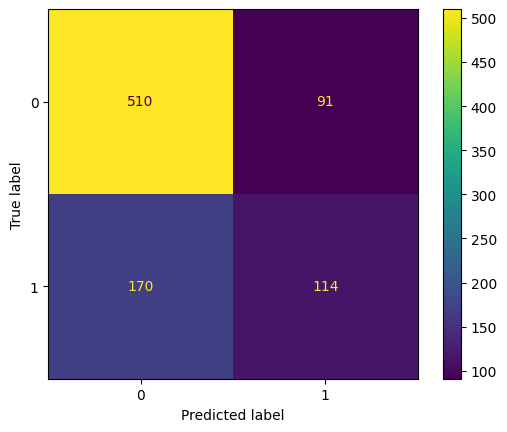

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_limpio,
    X_test_patron,
    y_test_patron
)
plt.show()

Train original: 3539 | Train limpio: 1847
Test original:  885  | Test limpio:  451
✅ Modelo reentrenado

=== MODELO ORIGINAL (en subset limpio) ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       364
           1       0.53      0.23      0.32        87

    accuracy                           0.81       451
   macro avg       0.68      0.59      0.61       451
weighted avg       0.78      0.81      0.78       451



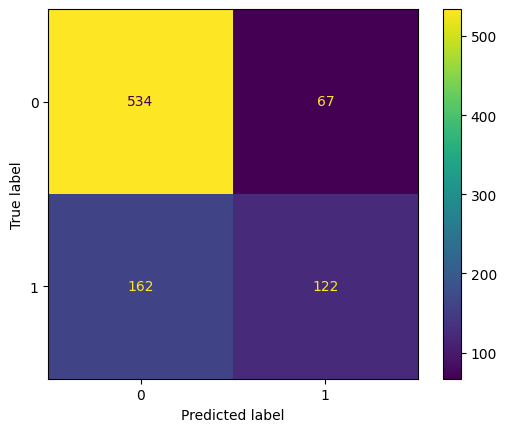

In [ ]:
# ── Paso 1: filtrar TRAIN ──────────────────────────────────
mask_train_limpio = (
    (X_train['Gender'] != 1) &
    (~X_train['Marital status'].isin([2, 4, 6])) &
    (~X_train['Course'].isin([33, 9853, 9119, 171]))
)
X_train_limpio = X_train[mask_train_limpio]
y_train_limpio = y_train[mask_train_limpio]

# ── Paso 2: filtrar TEST ───────────────────────────────────
mask_test_limpio = (
    (X_test['Gender'] != 1) &
    (~X_test['Marital status'].isin([2, 4, 6])) &
    (~X_test['Course'].isin([33, 9853, 9119, 171]))
)
X_test_limpio = X_test[mask_test_limpio]
y_test_limpio = y_test[mask_test_limpio]

print(f"Train original: {len(X_train)} | Train limpio: {len(X_train_limpio)}")
print(f"Test original:  {len(X_test)}  | Test limpio:  {len(X_test_limpio)}")

# ── Paso 3: reentrenar ─────────────────────────────────────
model_limpio = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0
)
model_limpio.fit(X_train_limpio, y_train_limpio)
print("✅ Modelo reentrenado")

# ── Paso 4: comparar ───────────────────────────────────────
y_pred_original_en_limpio = best_model.predict(X_test_limpio)

print("\n=== MODELO ORIGINAL (en subset limpio) ===")
print(classification_report(y_test_limpio, y_pred_original_en_limpio))

#print("\n=== MODELO REENTRENADO SIN SUBGRUPOS PROBLEMÁTICOS ===")
##print(classification_report(y_test_limpio, y_pred_limpio))

ConfusionMatrixDisplay.from_estimator(
    best_model_rf,
    X_test,
    y_test
)
plt.show()